In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from keras.utils import to_categorical

from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout


### Data Processing

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator(rescale = 1./255)
test_set = test_datagen.flow_from_directory('Dataset_2/test',
                                            target_size = (224, 224),
                                            batch_size = 32,
                                            class_mode = 'categorical',
                                            shuffle=False)

y_test = test_set.classes

Found 624 images belonging to 2 classes.


## Ensemble part

### Loading The model

In [7]:
from keras.models import load_model
from sklearn.metrics import accuracy_score
#loading models
model1 = load_model('model_vgg16.keras')
model2 = load_model('model_vgg19_2.keras')
model3 = load_model('model_resnet_50.keras')

models = [model1, model2, model3]

for model in models:
    model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

                                                                                                  
 conv1_bn (BatchNormalizati  (None, 112, 112, 64)         256       ['conv1_conv[0][0]']          
 on)                                                                                              
                                                                                                  
 conv1_relu (Activation)     (None, 112, 112, 64)         0         ['conv1_bn[0][0]']            
                                                                                                  
 pool1_pad (ZeroPadding2D)   (None, 114, 114, 64)         0         ['conv1_relu[0][0]']          
                                                                                                  
 pool1_pool (MaxPooling2D)   (None, 56, 56, 64)           0         ['pool1_pad[0][0]']           
                                                                                                  
 conv2_blo

 ation)                                                                                           
                                                                                                  
 conv2_block3_2_conv (Conv2  (None, 56, 56, 64)           36928     ['conv2_block3_1_relu[0][0]'] 
 D)                                                                                               
                                                                                                  
 conv2_block3_2_bn (BatchNo  (None, 56, 56, 64)           256       ['conv2_block3_2_conv[0][0]'] 
 rmalization)                                                                                     
                                                                                                  
 conv2_block3_2_relu (Activ  (None, 56, 56, 64)           0         ['conv2_block3_2_bn[0][0]']   
 ation)                                                                                           
          

 conv3_block2_add (Add)      (None, 28, 28, 512)          0         ['conv3_block1_out[0][0]',    
                                                                     'conv3_block2_3_bn[0][0]']   
                                                                                                  
 conv3_block2_out (Activati  (None, 28, 28, 512)          0         ['conv3_block2_add[0][0]']    
 on)                                                                                              
                                                                                                  
 conv3_block3_1_conv (Conv2  (None, 28, 28, 128)          65664     ['conv3_block2_out[0][0]']    
 D)                                                                                               
                                                                                                  
 conv3_block3_1_bn (BatchNo  (None, 28, 28, 128)          512       ['conv3_block3_1_conv[0][0]'] 
 rmalizati

                                                                                                  
 conv4_block1_0_conv (Conv2  (None, 14, 14, 1024)         525312    ['conv3_block4_out[0][0]']    
 D)                                                                                               
                                                                                                  
 conv4_block1_3_conv (Conv2  (None, 14, 14, 1024)         263168    ['conv4_block1_2_relu[0][0]'] 
 D)                                                                                               
                                                                                                  
 conv4_block1_0_bn (BatchNo  (None, 14, 14, 1024)         4096      ['conv4_block1_0_conv[0][0]'] 
 rmalization)                                                                                     
                                                                                                  
 conv4_blo

 rmalization)                                                                                     
                                                                                                  
 conv4_block4_1_relu (Activ  (None, 14, 14, 256)          0         ['conv4_block4_1_bn[0][0]']   
 ation)                                                                                           
                                                                                                  
 conv4_block4_2_conv (Conv2  (None, 14, 14, 256)          590080    ['conv4_block4_1_relu[0][0]'] 
 D)                                                                                               
                                                                                                  
 conv4_block4_2_bn (BatchNo  (None, 14, 14, 256)          1024      ['conv4_block4_2_conv[0][0]'] 
 rmalization)                                                                                     
          

 conv4_block6_out (Activati  (None, 14, 14, 1024)         0         ['conv4_block6_add[0][0]']    
 on)                                                                                              
                                                                                                  
 conv5_block1_1_conv (Conv2  (None, 7, 7, 512)            524800    ['conv4_block6_out[0][0]']    
 D)                                                                                               
                                                                                                  
 conv5_block1_1_bn (BatchNo  (None, 7, 7, 512)            2048      ['conv5_block1_1_conv[0][0]'] 
 rmalization)                                                                                     
                                                                                                  
 conv5_block1_1_relu (Activ  (None, 7, 7, 512)            0         ['conv5_block1_1_bn[0][0]']   
 ation)   

                                                                                                  
 conv5_block3_2_relu (Activ  (None, 7, 7, 512)            0         ['conv5_block3_2_bn[0][0]']   
 ation)                                                                                           
                                                                                                  
 conv5_block3_3_conv (Conv2  (None, 7, 7, 2048)           1050624   ['conv5_block3_2_relu[0][0]'] 
 D)                                                                                               
                                                                                                  
 conv5_block3_3_bn (BatchNo  (None, 7, 7, 2048)           8192      ['conv5_block3_3_conv[0][0]'] 
 rmalization)                                                                                     
                                                                                                  
 conv5_blo

In [36]:
#Weighted average ensemble
preds = [model.predict(X_test) for model in models]
preds=np.array(preds)


20/20 [==============================] - 82s 4s/step


In [37]:
summed = np.sum(preds, axis=0)
ensemble_prediction = np.argmax(summed,axis=1)

prediction1 = preds[0]
prediction1_classification = np.argmax(prediction1, axis=1)

prediction2 = preds[1]
prediction2_classification = np.argmax(prediction2, axis=1)

prediction3 = preds[2]
prediction3_classification = np.argmax(prediction3, axis=1)


In [38]:
accuracy1 = accuracy_score(y_test,prediction1_classification)
accuracy2 = accuracy_score(y_test,prediction2_classification)
accuracy3 = accuracy_score(y_test,prediction3_classification)
ensemble_accuracy = accuracy_score(y_test,ensemble_prediction)

weights = [0.4, 0.4, 0.2] #arbitrary weights

In [39]:
#Using tensordot to sum the products of all elements over specified axes.
weighted_preds = np.tensordot(preds, weights, axes=((0),(0)))
weighted_ensemble_prediction = np.argmax(weighted_preds, axis=1)

weighted_accuracy = accuracy_score(y_test, weighted_ensemble_prediction)

print('Accuracy Score for model1 = ', accuracy1)
print('Accuracy Score for model2 = ', accuracy2)
print('Accuracy Score for model3 = ', accuracy3)
print('Accuracy Score for average ensemble = ', ensemble_accuracy)
print('Accuracy Score for weighted average ensemble = ', weighted_accuracy)

Accuracy Score for model1 =  0.9150641025641025
Accuracy Score for model2 =  0.875
Accuracy Score for model3 =  0.8766025641025641
Accuracy Score for average ensemble =  0.9150641025641025
Accuracy Score for weighted average ensemble =  0.905448717948718


### Performance of Individual Model

#### VGG 16

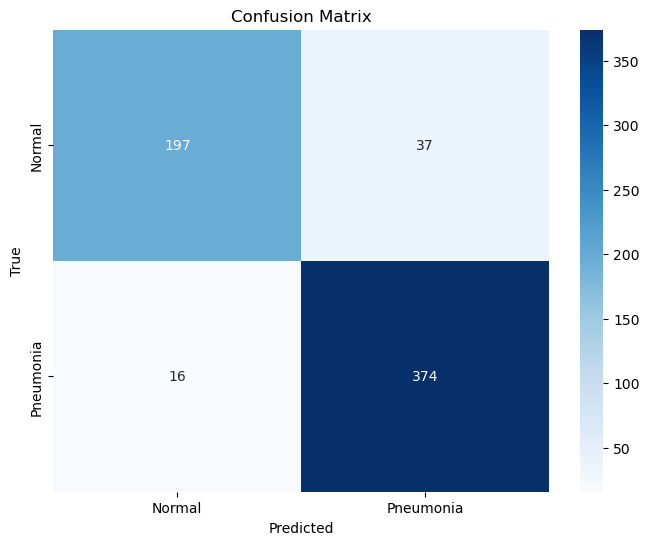

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
conf_matrix = confusion_matrix(y_test, prediction1_classification) 

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [44]:
from sklearn.metrics import classification_report
class_names = ["Normal", "Pneumonia"]
report = classification_report(y_test, prediction1_classification, target_names=class_names)
print(report)

              precision    recall  f1-score   support

      Normal       0.92      0.84      0.88       234
   Pneumonia       0.91      0.96      0.93       390

    accuracy                           0.92       624
   macro avg       0.92      0.90      0.91       624
weighted avg       0.92      0.92      0.91       624



#### VGG 19

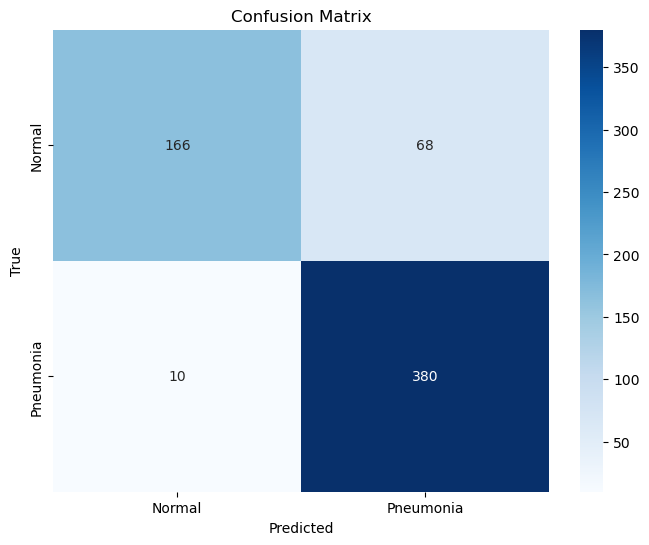

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
conf_matrix = confusion_matrix(y_test, prediction2_classification) 

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [47]:
from sklearn.metrics import classification_report
class_names = ["Normal", "Pneumonia"]
report = classification_report(y_test, prediction2_classification, target_names=class_names)
print(report)

              precision    recall  f1-score   support

      Normal       0.94      0.71      0.81       234
   Pneumonia       0.85      0.97      0.91       390

    accuracy                           0.88       624
   macro avg       0.90      0.84      0.86       624
weighted avg       0.88      0.88      0.87       624



#### ResNet 50

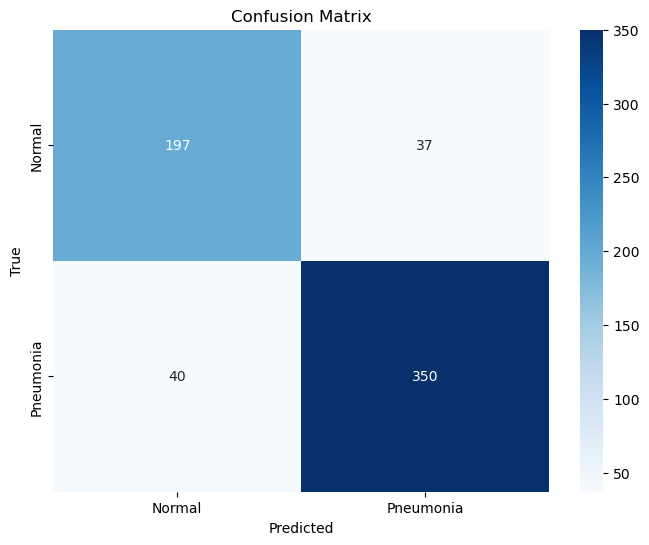

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
conf_matrix = confusion_matrix(y_test, prediction3_classification) 

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [49]:
from sklearn.metrics import classification_report
class_names = ["Normal", "Pneumonia"]
report = classification_report(y_test, prediction3_classification, target_names=class_names)
print(report)

              precision    recall  f1-score   support

      Normal       0.83      0.84      0.84       234
   Pneumonia       0.90      0.90      0.90       390

    accuracy                           0.88       624
   macro avg       0.87      0.87      0.87       624
weighted avg       0.88      0.88      0.88       624



#### Average Ensemble

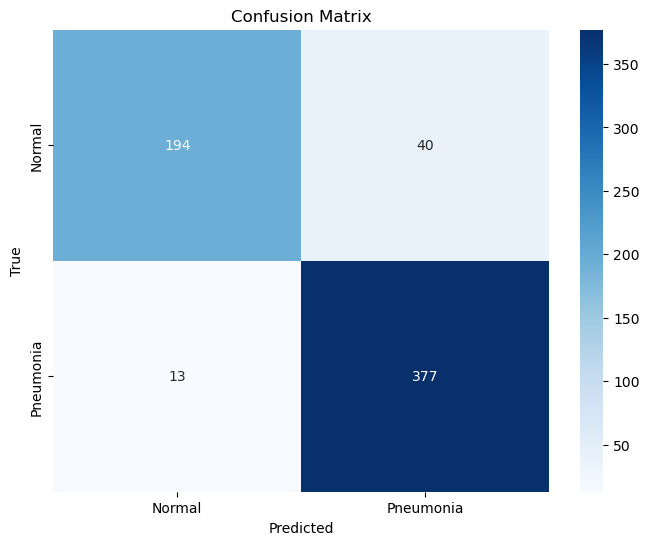

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
conf_matrix = confusion_matrix(y_test, ensemble_prediction)  # You can use any of the label variables

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [51]:
from sklearn.metrics import classification_report
class_names = ["Normal", "Pneumonia"]
report = classification_report(y_test, ensemble_prediction, target_names=class_names)
print(report)

              precision    recall  f1-score   support

      Normal       0.94      0.83      0.88       234
   Pneumonia       0.90      0.97      0.93       390

    accuracy                           0.92       624
   macro avg       0.92      0.90      0.91       624
weighted avg       0.92      0.92      0.91       624



#### Sample Ensemble 

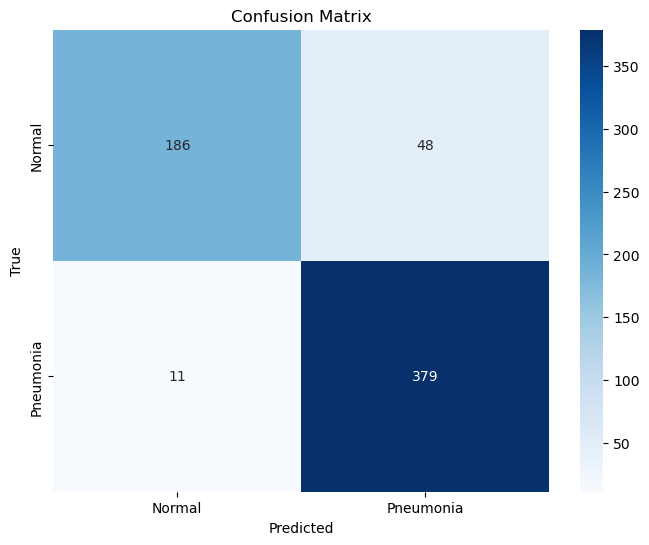

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
conf_matrix = confusion_matrix(y_test, weighted_ensemble_prediction)  # You can use any of the label variables

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [53]:
from sklearn.metrics import classification_report
class_names = ["Normal", "Pneumonia"]
report = classification_report(y_test, weighted_ensemble_prediction, target_names=class_names)
print(report)

              precision    recall  f1-score   support

      Normal       0.94      0.79      0.86       234
   Pneumonia       0.89      0.97      0.93       390

    accuracy                           0.91       624
   macro avg       0.92      0.88      0.90       624
weighted avg       0.91      0.91      0.90       624



### Searching for the best weight

In [40]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score

df_list = []

for w1 in range(0, 10):
    for w2 in range(0, 10):
        for w3 in range(0, 10):
            wts = [w1/10., w2/10., w3/10.]
            wted_preds1 = np.tensordot(preds, wts, axes=((0),(0)))
            wted_ensemble_pred = np.argmax(wted_preds1, axis=1)
            weighted_accuracy = accuracy_score(y_test, wted_ensemble_pred)
            
            df_list.append({'wt1': wts[0], 'wt2': wts[1], 'wt3': wts[2], 'acc': weighted_accuracy * 100})

df = pd.DataFrame(df_list)

max_acc_row = df.iloc[df['acc'].idxmax()]
print("Max accuracy of", max_acc_row['acc'], "obtained with w1 =", max_acc_row['wt1'],
      "w2 =", max_acc_row['wt2'], "and w3 =", max_acc_row['wt3'])


Max accuracy of 92.3076923076923 obtained with w1 = 0.8 w2 = 0.3 and w3 = 0.1


### Exploring the model for the Ideal Model

In [41]:
ideal_weights = [0.8,0.3,0.1]
weighted_ideal_preds = np.tensordot(preds, ideal_weights, axes=((0),(0)))
weighted_ideal_prediction = np.argmax(weighted_ideal_preds, axis=1)

weighted_ideal_accuracy = accuracy_score(y_test, weighted_ideal_prediction)

print('Accuracy Score for weighted average ensemble = ', weighted_ideal_accuracy)


Accuracy Score for weighted average ensemble =  0.9230769230769231


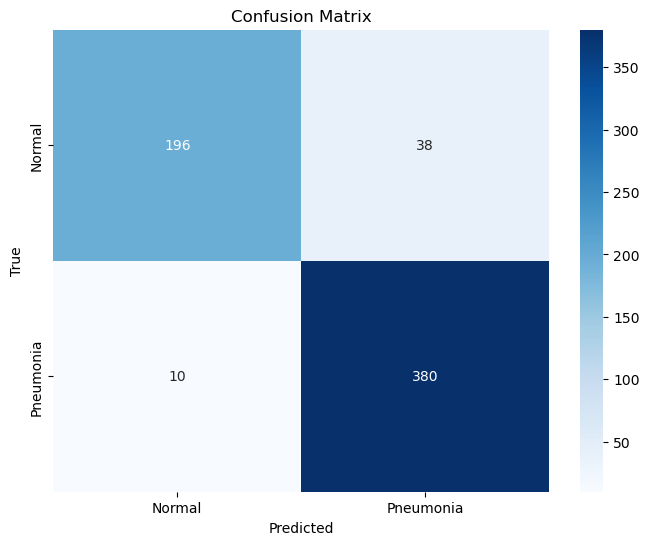

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
conf_matrix = confusion_matrix(y_test, weighted_ideal_prediction)  # You can use any of the label variables

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [32]:
from sklearn.metrics import classification_report
class_names = ["Normal", "Pneumonia"]
report = classification_report(y_test, weighted_ideal_prediction, target_names=class_names)
print(report)

              precision    recall  f1-score   support

      Normal       0.95      0.84      0.89       234
   Pneumonia       0.91      0.97      0.94       390

    accuracy                           0.92       624
   macro avg       0.93      0.91      0.92       624
weighted avg       0.92      0.92      0.92       624

